# CSE5280 — Evacuation Simulation: Three-Floor Building
**Crawford Building | Per-Floor Gradient-Descent Navigation**

*Department of Electrical Engineering and Computer Science — Florida Institute of Technology*

---

### Design: Every agent navigates their current floor's layout

```
Floor 2 agent  →  navigate Floor 2 corridors/walls  →  reach Ramp 2 entry
                  descend Ramp 2  (z: 6 → 3)
Floor 1 agent  →  navigate Floor 1 corridors/walls  →  reach Ramp 1 entry
                  descend Ramp 1  (z: 3 → 0)
Floor 0 agent  →  navigate Ground corridors/walls   →  Exit A or Exit B (soft-min)
```

**All motion emerges from gradient descent on a scalar cost function.**
No path planning, no teleportation, no hard floor-switching.

| Rubric Category | Points |
|---|---|
| Cost-function formulation (5 terms + soft-min) | 25 |
| Ramp modeling (capsule footprint + linear height) | 20 |
| Multi-agent behavior (20 agents, 3 floors) | 20 |
| Two-exit behavior (soft-min split) | 10 |
| Stability (momentum + step cap + noise) | 10 |
| Visualization quality (vedo 3D from your floor files) | 10 |
| Report clarity | 5 |


## 1. Imports & Setup

In [1]:
# Uncomment if running in Colab:
# !pip install vedo numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os, sys, subprocess

import vedo
# Uncomment ONE of these for notebook-inline 3-D rendering:
# vedo.settings.default_backend = 'trame'   # Colab
# vedo.settings.default_backend = 'k3d'     # JupyterLab

H = 3.0     # floor-to-floor height
W = 0.2     # wall thickness
print(f"vedo {vedo.__version__}  |  numpy {np.__version__}")


vedo 2026.6.1  |  numpy 2.4.2


## 2. Building Constants

Three floors at $z = 0,\ H,\ 2H$ with $H=3$.

**Exits** (ground floor only):
- Exit A — west wall gap $x=0,\ y\in[6,9]$, centre $(0,\ 7.5,\ 0)$
- Exit B — north wall gap $y=14,\ x\in[16,19]$, centre $(17.5,\ 14,\ 0)$

**Ramps:**
- Ramp 1: Ground → Floor 1, centerline $(19,7)\to(23,7)$, $z:0\to H$
- Ramp 2: Floor 1 → Floor 2, centerline $(23,10)\to(19,10)$, $z:H\to 2H$

**Ramp waypoints** — the target agents aim for on each upper floor (mid-entry point):
- Floor 2 agents aim for $(21,\ 10,\ 2H)$ — Ramp 2 mid-entry
- Floor 1 agents aim for $(21,\ 7,\ H)$ — Ramp 1 mid-entry


In [2]:
# ── Exits ─────────────────────────────────────────────────────────────────────
EXIT_A = np.array([0.0,  7.5, 0.0])
EXIT_B = np.array([17.5, 14.0, 0.0])
EXITS  = [EXIT_A, EXIT_B]

# ── Ramps ─────────────────────────────────────────────────────────────────────
RAMP1 = dict(A=np.array([19., 7.]), B=np.array([23., 7.]), z0=0.,  z1=H,   r=1.0)
RAMP2 = dict(A=np.array([23.,10.]), B=np.array([19.,10.]), z0=H,   z1=2*H, r=1.0)
RAMPS = [RAMP1, RAMP2]

# ── Ramp waypoints per floor (xy target agents walk toward) ───────────────────
# Using mid-ramp x so agents enter the capsule before the cost switches
RAMP_WP = {
    2: np.array([21., 10., 2*H]),   # Floor 2 → aim for Ramp 2 mid
    1: np.array([21.,  7.,  H  ]),  # Floor 1 → aim for Ramp 1 mid
}

# ── Wall segments (from your floor files) ────────────────────────────────────
# Ground floor (floor1.py wall_segments)
WALLS_F0 = [
    ((0,0),(10,0)),((10,0),(15,0)),((15,0),(20,0)),((20,0),(25,0)),
    ((0,0),(0,5)),((0,5),(0,6)),((0,9),(0,10)),((0,10),(0,14)),
    ((0,14),(10,14)),((10,14),(15,14)),((15,14),(16,14)),
    ((19,14),(20,14)),((20,14),(25,14)),
    ((25,0),(25,3)),((25,3),(25,11)),((25,11),(25,14)),
    ((10,0),(10,5)),((10,10),(10,14)),
    ((15,0),(15,2)),((15,2),(15,5)),((15,10),(15,14)),
    ((20,0),(20,2)),((20,2),(20,3)),((20,12),(20,14)),
    ((0,5),(6,5)),((9,5),(10,5)),((12,5),(15,5)),
    ((0,10),(6,10)),((9,10),(13,10)),
    ((15,2),(16,2)),((18,2),(20,2)),
    ((22,3),(25,3)),((20,11),(25,11)),
]
# Upper floors (floor2.py / floor3.py wall_segments — identical footprint)
WALLS_UPPER = [
    ((0,0),(10,0)),((10,0),(15,0)),((15,0),(25,0)),
    ((0,0),(0,7)),((0,7),(0,14)),
    ((0,14),(10,14)),((10,14),(15,14)),((15,14),(20,14)),((20,14),(25,14)),
    ((25,0),(25,4)),((25,4),(25,14)),
    ((18,4),(20,4)),((20,4),(25,4)),
    ((15,0),(15,4)),
    ((10,0),(10,2)),((10,4),(10,7)),((10,7),(10,11)),((10,13),(10,14)),
    ((0,7),(10,7)),
]
WALLS = {0: WALLS_F0, 1: WALLS_UPPER, 2: WALLS_UPPER}

print("Constants loaded.")
print(f"  Floor 0 wall segments : {len(WALLS_F0)}")
print(f"  Upper  wall segments  : {len(WALLS_UPPER)}")
print(f"  Ramp 1 : {RAMP1['A']} → {RAMP1['B']}  z: {RAMP1['z0']} → {RAMP1['z1']}")
print(f"  Ramp 2 : {RAMP2['A']} → {RAMP2['B']}  z: {RAMP2['z0']} → {RAMP2['z1']}")


Constants loaded.
  Floor 0 wall segments : 33
  Upper  wall segments  : 19
  Ramp 1 : [19.  7.] → [23.  7.]  z: 0.0 → 3.0
  Ramp 2 : [23. 10.] → [19. 10.]  z: 3.0 → 6.0


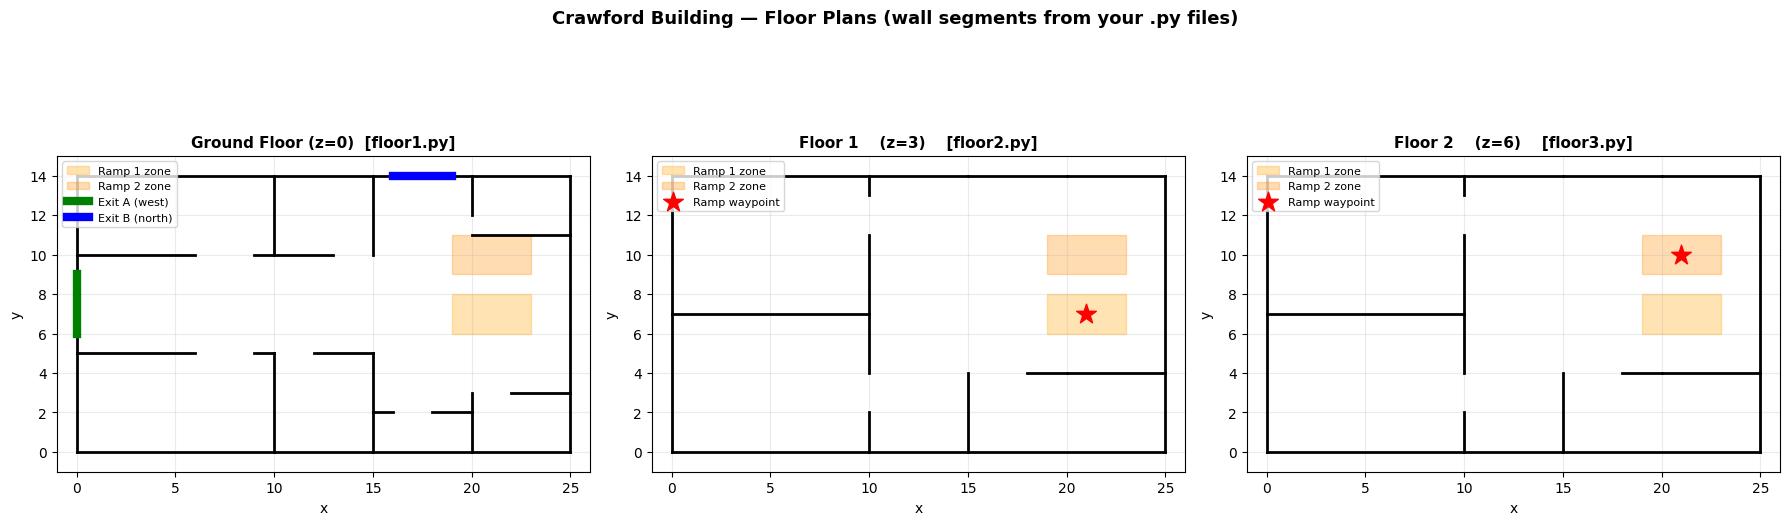

In [3]:
# ── Visualise floor plans with wall segments, exits, ramp zones ───────────────
fig, axs = plt.subplots(1, 3, figsize=(18,6))
floor_titles = ['Ground Floor (z=0)  [floor1.py]',
                'Floor 1    (z=3)    [floor2.py]',
                'Floor 2    (z=6)    [floor3.py]']

for fi, (ax, title) in enumerate(zip(axs, floor_titles)):
    # Walls
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=2)
    # Ramp zones
    ax.add_patch(plt.Rectangle((19,6),4,2, color='orange',     alpha=0.30, label='Ramp 1 zone'))
    ax.add_patch(plt.Rectangle((19,9),4,2, color='darkorange', alpha=0.30, label='Ramp 2 zone'))
    # Exits on ground floor only
    if fi == 0:
        ax.plot([0,0],[6,9],  'g-', lw=6, label='Exit A (west)')
        ax.plot([16,19],[14,14],'b-',lw=6, label='Exit B (north)')
    # Ramp waypoint
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0],wp[1], c='red', s=220, marker='*', zorder=6, label='Ramp waypoint')
    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)

plt.suptitle('Crawford Building — Floor Plans (wall segments from your .py files)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 3. Ramp Modeling  *(20 points)*

A ramp is a piecewise-planar surface patch embedded in $\mathbb{R}^3$.

**Step 1 — Centerline projection:**
$$u(x,y) = \text{clip}\!\left(\frac{(P-A)\cdot v}{\|v\|^2},\ 0,\ 1\right), \quad v = B - A$$

**Step 2 — Linear height interpolation:**
$$z_{\text{ramp}}(x,y) = z_0 + (z_1 - z_0)\,u(x,y)$$

**Step 3 — Capsule footprint** of half-width $r$:
$$\mathcal{R} = \{(x,y)\mid \text{dist}((x,y),\,[A,B]) \le r\}$$

**Step 4 — Surface blending:**
$$z_{\text{surf}}(x,y) = (1-g)\,z_{\text{floor}} + g\,z_{\text{ramp}}(x,y), \quad
g = \mathbf{1}_{(x,y)\in\mathcal{R}}$$

Outside the capsule the surface is flat; inside it follows the incline.


In [4]:
# ── Ramp geometry ─────────────────────────────────────────────────────────────

def dist_seg(xy, A, B):
    """2-D distance from point xy to segment A–B."""
    v = B - A;  w = xy - A
    t = np.clip(np.dot(w,v)/np.dot(v,v), 0., 1.)
    return float(np.linalg.norm(xy - (A + t*v)))

def ramp_u(xy, ramp):
    v = ramp['B'] - ramp['A']
    return float(np.clip(np.dot(xy-ramp['A'], v)/np.dot(v,v), 0., 1.))

def ramp_height(xy, ramp):
    return ramp['z0'] + (ramp['z1']-ramp['z0']) * ramp_u(xy, ramp)

def in_ramp(xy, ramp):
    return dist_seg(xy, ramp['A'], ramp['B']) <= ramp['r']

def z_surf(xy, floor_z):
    """Blended surface height — flat floor outside ramp capsule, incline inside."""
    for ramp in RAMPS:
        if in_ramp(xy, ramp):
            return ramp_height(xy, ramp)
    return float(floor_z)

def get_floor_z(z):
    """Snap DOWN to highest floor base ≤ z (prevents pulling agent to wrong floor)."""
    floors = [0., H, 2*H]
    below  = [fz for fz in floors if fz <= z + 0.01]
    return float(below[-1]) if below else 0.

def detect_floor(z):
    """Return floor index 0/1/2 from z coordinate."""
    if   z < H*0.6:  return 0
    elif z < H*1.6:  return 1
    else:            return 2

# ── Sanity checks ─────────────────────────────────────────────────────────────
print("Ramp 1 (Ground→Floor1):  A=(19,7) z=0,  mid=(21,7) z=1.5,  B=(23,7) z=3")
for xy, exp in [([19,7], 0.), ([21,7], 1.5), ([23,7], H)]:
    got = ramp_height(np.array(xy,float), RAMP1)
    ok  = '✓' if abs(got-exp)<0.01 else '✗'
    print(f"  z_ramp{xy} = {got:.2f}  expected {exp:.2f}  {ok}")

print("Ramp 2 (Floor1→Floor2):  A=(23,10) z=3,  mid=(21,10) z=4.5,  B=(19,10) z=6")
for xy, exp in [([23,10], H), ([21,10], 4.5), ([19,10], 2*H)]:
    got = ramp_height(np.array(xy,float), RAMP2)
    ok  = '✓' if abs(got-exp)<0.01 else '✗'
    print(f"  z_ramp{xy} = {got:.2f}  expected {exp:.2f}  {ok}")


Ramp 1 (Ground→Floor1):  A=(19,7) z=0,  mid=(21,7) z=1.5,  B=(23,7) z=3
  z_ramp[19, 7] = 0.00  expected 0.00  ✓
  z_ramp[21, 7] = 1.50  expected 1.50  ✓
  z_ramp[23, 7] = 3.00  expected 3.00  ✓
Ramp 2 (Floor1→Floor2):  A=(23,10) z=3,  mid=(21,10) z=4.5,  B=(19,10) z=6
  z_ramp[23, 10] = 3.00  expected 3.00  ✓
  z_ramp[21, 10] = 4.50  expected 4.50  ✓
  z_ramp[19, 10] = 6.00  expected 6.00  ✓


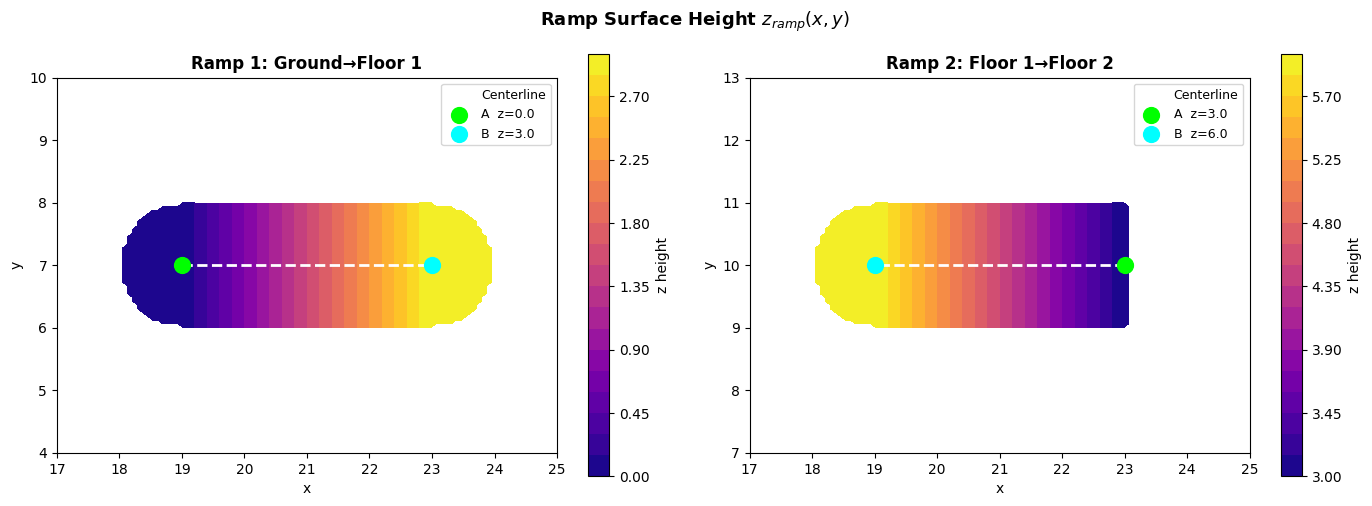

In [5]:
# ── Visualise ramp height maps ────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(14,5))
for ax, ramp, title in zip(axs, [RAMP1, RAMP2],
                            ['Ramp 1: Ground→Floor 1', 'Ramp 2: Floor 1→Floor 2']):
    A, B, r = ramp['A'], ramp['B'], ramp['r']
    xs = np.linspace(min(A[0],B[0])-2, max(A[0],B[0])+2, 100)
    ys = np.linspace(min(A[1],B[1])-3, max(A[1],B[1])+3, 100)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.full_like(XX, np.nan)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            xy = np.array([XX[i,j], YY[i,j]])
            if dist_seg(xy, A, B) <= r:
                ZZ[i,j] = ramp_height(xy, ramp)
    cp = ax.contourf(XX, YY, ZZ, levels=20, cmap='plasma')
    plt.colorbar(cp, ax=ax, label='z height')
    ax.plot([A[0],B[0]], [A[1],B[1]], 'w--', lw=2, label='Centerline')
    ax.scatter(*A, c='lime', s=130, zorder=5, label=f'A  z={ramp["z0"]}')
    ax.scatter(*B, c='cyan', s=130, zorder=5, label=f'B  z={ramp["z1"]}')
    ax.set_title(title, fontweight='bold')
    ax.set_aspect('equal'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(fontsize=9)
plt.suptitle('Ramp Surface Height $z_{ramp}(x,y)$', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 5. Finite-Difference Gradient  *(Stability — 10 points)*

Central differences with $\varepsilon = 10^{-4}$:

$$\frac{\partial C}{\partial p_k}\approx
\frac{C(p+\varepsilon e_k)-C(p-\varepsilon e_k)}{2\varepsilon},
\quad k\in\{x,y,z\}$$

**Momentum update:**
$$v_i^{k+1} = \beta\,v_i^k - \alpha\,\nabla C + \eta_i$$
$$p_i^{k+1} = p_i^k + \text{clip}(v_i^{k+1},\,-s_{\max},\,s_{\max})$$

Noise $\eta_z = 0$ — only horizontal noise, $C_{\text{height}}$ handles vertical.


In [6]:
def fd_gradient(i, positions, p_old, floor_idx, eps=1e-4, **kw):
    """Central-difference gradient of total_cost w.r.t. positions[i]. Returns (3,)."""
    grad = np.zeros(3)
    pos  = [np.array(q, dtype=float) for q in positions]
    for k in range(3):
        pos[i][k] += eps
        Cp = total_cost(i, pos, p_old, floor_idx, **kw)
        pos[i][k] -= 2*eps
        Cm = total_cost(i, pos, p_old, floor_idx, **kw)
        pos[i][k] += eps          # restore
        grad[k] = (Cp - Cm) / (2*eps)
    return grad

print("Finite-difference gradient defined.")


Finite-difference gradient defined.


## 4. Cost Function  *(25 points)*

$$C = C_{\text{goal}} + C_{\text{walls}} + C_{\text{height}} + C_{\text{smooth}} + C_{\text{repulsion}}$$

---

### 4.1  Floor-Aware Goal Attraction

The target changes every step based on `detect_floor(z)`:

$$C_{\text{goal}}(p,\ f) = \begin{cases}
-\tau\log\!\displaystyle\sum_{i=1}^{2}\exp\!\left(-\dfrac{\|p-p_i^{\text{exit}}\|^2}{\tau}\right) & f=0
\quad\text{(soft-min, required)}\\[8pt]
w_{\text{wp}}\,\bigl((p_x - wp_x)^2 + (p_y - wp_y)^2\bigr) & f=1\text{ or }2
\end{cases}$$

- **Floor 0** — soft-min pulls agent to whichever exit is closer; $\tau=1.0$ gives a smooth split
- **Floor 1** — squared-distance pull in $(x,y)$ toward Ramp 1 mid-entry $(21,7)$
- **Floor 2** — squared-distance pull in $(x,y)$ toward Ramp 2 mid-entry $(21,10)$

Because `C_walls` uses each floor's real wall layout, agents must **navigate corridors and door
gaps** to reach the waypoint — they cannot pass through walls.

---

### 4.2  Wall Penalty — Quadratic Band

$$C_{\text{walls}}(p,\ f) = \sum_k w_{\text{wall}}\,(\text{band}-d_k)^2\,\mathbf{1}_{d_k<\text{band}}$$

$d_k$ = distance from agent $(x,y)$ to wall segment $k$ on floor $f$.  
Parameters: $\text{band}=0.6$, $w_{\text{wall}}=12$.

---

### 4.3  Surface Adherence

$$C_{\text{height}} = w_h\,(z - z_{\text{surf}}(x,y))^2, \quad w_h = 50$$

Once an agent enters a ramp capsule footprint, $z_{\text{surf}}$ becomes the inclined ramp
surface — the gradient of $C_{\text{height}}$ automatically rides the agent down.

---

### 4.4  Smoothness & Repulsion

$$C_{\text{smooth}} = w_s\,\|p^{k+1}-p^k\|^2 \qquad
C_{\text{rep}} = \sum_{j\ne i} w_{\text{rep}}(r_{\text{rep}}-\|p_i-p_j\|)^2_+$$


In [7]:
# ── Cost functions ────────────────────────────────────────────────────────────

def cost_goal(p, floor_idx, tau=1.0, w_wp=30.0):
    """
    Floor-aware goal:
      floor 0  → soft-min over Exit A, Exit B
      floor 1  → squared distance to Ramp-1 waypoint (xy only)
      floor 2  → squared distance to Ramp-2 waypoint (xy only)
    """
    p = np.asarray(p, dtype=float)
    if floor_idx == 0:
        # Soft-min (required by assignment)
        exps = []
        for e in EXITS:
            d2 = (p[0]-e[0])**2 + (p[1]-e[1])**2 + 0.05*(p[2]-e[2])**2
            exps.append(np.exp(-float(d2)/tau))
        return float(-tau * np.log(max(sum(exps), 1e-300)))
    else:
        wp   = RAMP_WP[floor_idx]
        # Pull only in xy — C_height handles z
        return float(w_wp * ((p[0]-wp[0])**2 + (p[1]-wp[1])**2))

def cost_walls(p, floor_idx, band=0.6, w_wall=12.0):
    """Quadratic band penalty — uses the correct floor's wall list."""
    xy    = np.asarray(p, dtype=float)[:2]
    total = 0.
    for (x1,y1),(x2,y2) in WALLS[floor_idx]:
        d = dist_seg(xy, np.array([x1,y1],float), np.array([x2,y2],float))
        if d < band:
            total += w_wall * (band - d)**2
    return total

def cost_height(p, w_h=50.0):
    """Keep agent glued to floor surface or ramp incline."""
    p  = np.asarray(p, dtype=float)
    fz = get_floor_z(p[2])
    return float(w_h * (p[2] - z_surf(p[:2], fz))**2)

def cost_smooth(p_new, p_old, w_s=0.2):
    d = np.asarray(p_new,float) - np.asarray(p_old,float)
    return float(w_s * np.dot(d,d))

def cost_repulsion(i, positions, r_rep=0.9, w_rep=6.0):
    total = 0.
    pi = positions[i]
    for j, pj in enumerate(positions):
        if j == i: continue
        d = float(np.linalg.norm(pi - pj))
        if 1e-6 < d < r_rep:
            total += w_rep * (r_rep - d)**2
    return total

def total_cost(i, positions, p_old, floor_idx,
               tau=1.0, w_wp=30.0, band=0.6, w_wall=12.0,
               w_h=50.0, w_s=0.2, r_rep=0.9, w_rep=6.0):
    p  = positions[i]
    C  = cost_goal(p, floor_idx, tau=tau, w_wp=w_wp)
    C += cost_walls(p, floor_idx, band=band, w_wall=w_wall)
    C += cost_height(p, w_h=w_h)
    C += cost_smooth(p, p_old, w_s=w_s)
    C += cost_repulsion(i, positions, r_rep=r_rep, w_rep=w_rep)
    return float(C)

print("All cost functions defined.")


All cost functions defined.


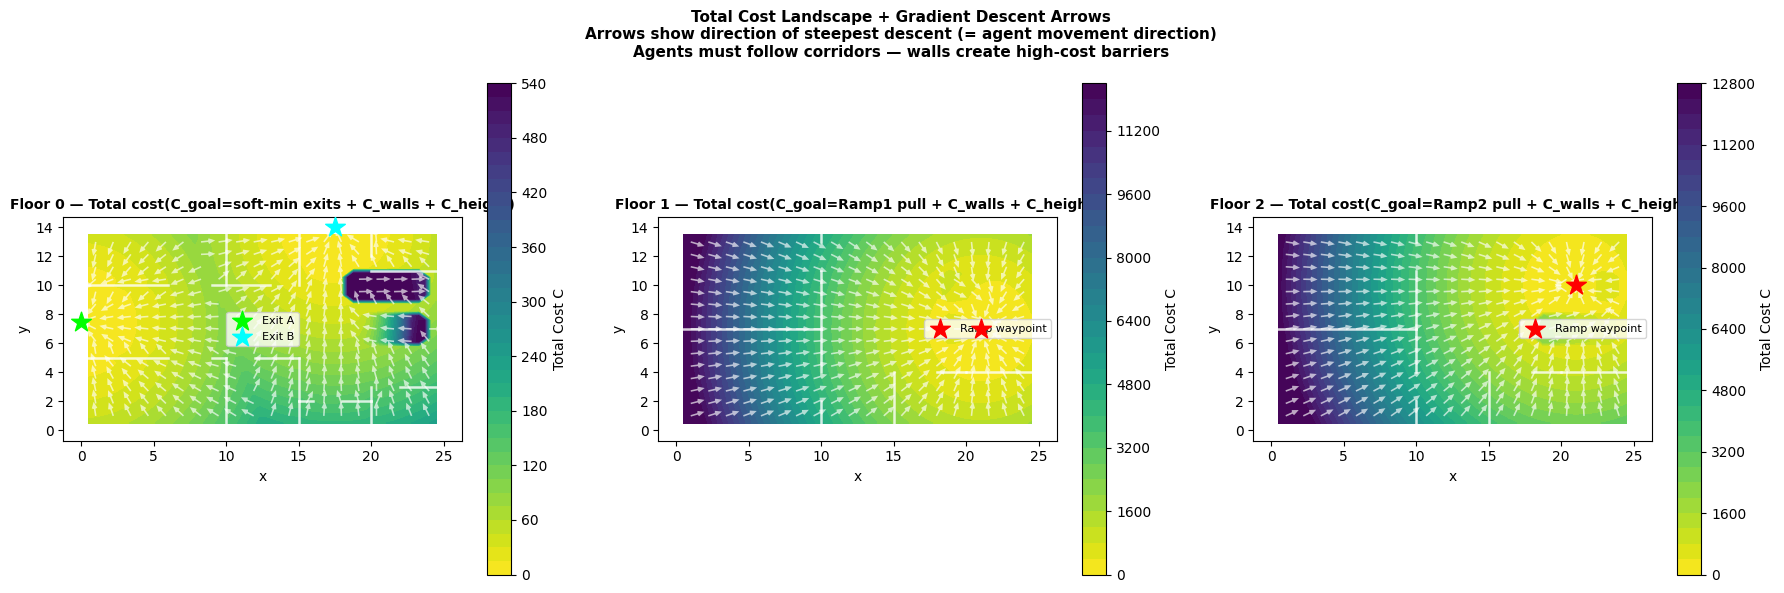

In [8]:
# ── Visualise TOTAL cost landscape per floor + gradient arrows ──────────────
# Uses a dummy 5-agent group so repulsion is near-zero for the landscape view.
# The gradient arrows show the direction each agent would move under the
# combined cost: C_goal + C_walls + C_height + C_smooth + C_repulsion

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
floor_zs   = [0., H, 2*H]
subtitles  = [
    'Floor 0 — Total cost(C_goal=soft-min exits + C_walls + C_height)',
    'Floor 1 — Total cost(C_goal=Ramp1 pull + C_walls + C_height)',
    'Floor 2 — Total cost(C_goal=Ramp2 pull + C_walls + C_height)',
]

# Coarse grid for cost heatmap
xs_c = np.linspace(0.5, 24.5, 60)
ys_c = np.linspace(0.5, 13.5, 45)
XX_c, YY_c = np.meshgrid(xs_c, ys_c)

# Fine grid for gradient arrows (quiver)
xs_q = np.linspace(1, 24, 20)
ys_q = np.linspace(1, 13, 15)
XX_q, YY_q = np.meshgrid(xs_q, ys_q)

for fi, (ax, fz, sub) in enumerate(zip(axs, floor_zs, subtitles)):

    # ── Cost heatmap ─────────────────────────────────────────────────────────
    ZZ = np.zeros_like(XX_c)
    # Use a single dummy agent; neighbours far away so C_rep ≈ 0
    dummy_positions = [np.array([100., 100., fz])] * 5   # 5 far-away dummies
    for i in range(XX_c.shape[0]):
        for j in range(XX_c.shape[1]):
            p = np.array([XX_c[i,j], YY_c[i,j], fz])
            dummy_positions[0] = p
            ZZ[i,j] = total_cost(0, dummy_positions, p, fi)

    # Clip extreme values for better colour contrast
    vmax = np.percentile(ZZ, 97)
    cp   = ax.contourf(XX_c, YY_c, np.clip(ZZ, 0, vmax),
                       levels=35, cmap='viridis_r')
    plt.colorbar(cp, ax=ax, label='Total Cost C')

    # ── Gradient arrow field ─────────────────────────────────────────────────
    UU = np.zeros_like(XX_q)
    VV = np.zeros_like(YY_q)
    dummy_positions = [np.array([100., 100., fz])] * 5
    for i in range(XX_q.shape[0]):
        for j in range(XX_q.shape[1]):
            p = np.array([XX_q[i,j], YY_q[i,j], fz])
            dummy_positions[0] = p
            g = fd_gradient(0, dummy_positions, p, fi)
            # Descent direction = -gradient (normalised for visibility)
            gxy = np.array([g[0], g[1]])
            nm  = np.linalg.norm(gxy)
            if nm > 1e-6:
                gxy = gxy / nm
            UU[i,j] = -gxy[0]   # descent direction
            VV[i,j] = -gxy[1]

    ax.quiver(XX_q, YY_q, UU, VV,
              color='white', alpha=0.65, scale=28, width=0.004,
              headwidth=3.5, headlength=4)

    # ── Walls ────────────────────────────────────────────────────────────────
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2], 'w-', lw=1.8, alpha=0.8)

    # ── Targets ──────────────────────────────────────────────────────────────
    if fi == 0:
        ax.scatter(*EXIT_A[:2], c='lime', s=220, marker='*',
                   zorder=6, label='Exit A')
        ax.scatter(*EXIT_B[:2], c='cyan', s=220, marker='*',
                   zorder=6, label='Exit B')
    else:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0], wp[1], c='red', s=220, marker='*',
                   zorder=6, label='Ramp waypoint')

    ax.set_title(sub, fontweight='bold', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal'); ax.legend(fontsize=8)

plt.suptitle(
    'Total Cost Landscape + Gradient Descent Arrows\n'
    'Arrows show direction of steepest descent (= agent movement direction)\n'
    'Agents must follow corridors — walls create high-cost barriers',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()


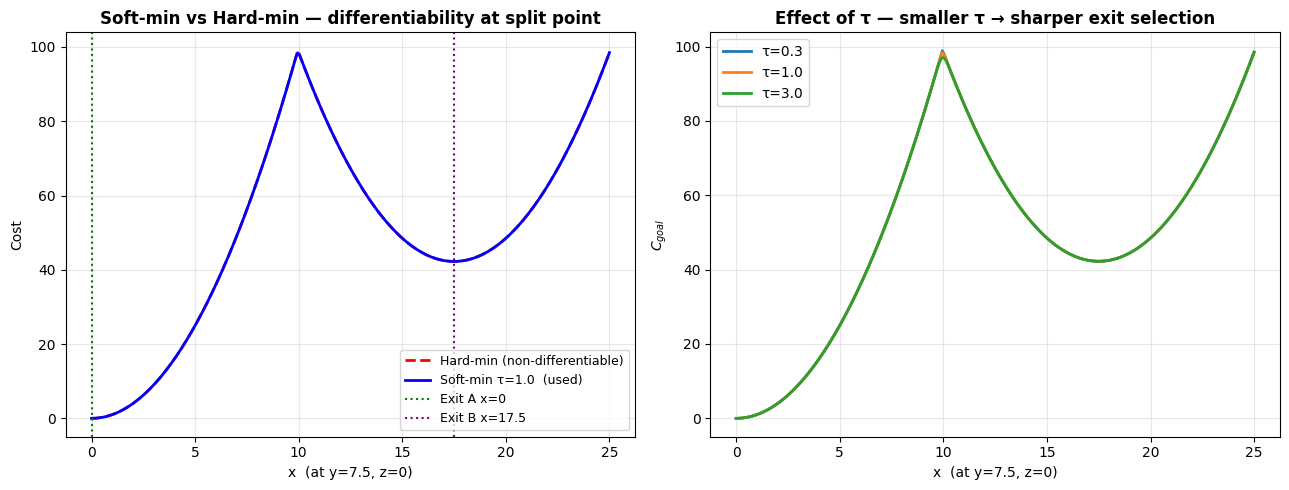

In [9]:
# ── Soft-min analysis (Floor 0) ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

xs_line = np.linspace(0, 25, 300)
p_line  = [np.array([x, 7.5, 0.0]) for x in xs_line]

hard = [min(np.dot(p-EXIT_A, p-EXIT_A), np.dot(p-EXIT_B, p-EXIT_B)) for p in p_line]
soft = [cost_goal(p, floor_idx=0, tau=1.0) for p in p_line]

ax1.plot(xs_line, hard, 'r--', lw=2, label='Hard-min (non-differentiable)')
ax1.plot(xs_line, soft, 'b-',  lw=2, label='Soft-min τ=1.0  (used)')
ax1.axvline(EXIT_A[0], color='green',  ls=':', label='Exit A x=0')
ax1.axvline(EXIT_B[0], color='purple', ls=':', label='Exit B x=17.5')
ax1.set_xlabel('x  (at y=7.5, z=0)'); ax1.set_ylabel('Cost')
ax1.set_title('Soft-min vs Hard-min — differentiability at split point', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

for tau in [0.3, 1.0, 3.0]:
    ax2.plot(xs_line, [cost_goal(p, 0, tau=tau) for p in p_line], lw=2, label=f'τ={tau}')
ax2.set_xlabel('x  (at y=7.5, z=0)'); ax2.set_ylabel('$C_{goal}$')
ax2.set_title('Effect of τ — smaller τ → sharper exit selection', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Agent Initialisation  *(Multi-agent — 20 points)*

**20 agents**: 6 on Ground (Floor 0), 6 on Floor 1, 8 on Floor 2.  
Each starts on flat floor (not on a ramp), sampled in $x\in[1,17],\ y\in[1,13]$.

Colour legend used throughout:
- 🔵 Blue — started Floor 0
- 🟠 Orange — started Floor 1
- 🔴 Red — started Floor 2


Agents per floor: [6, 6, 8]


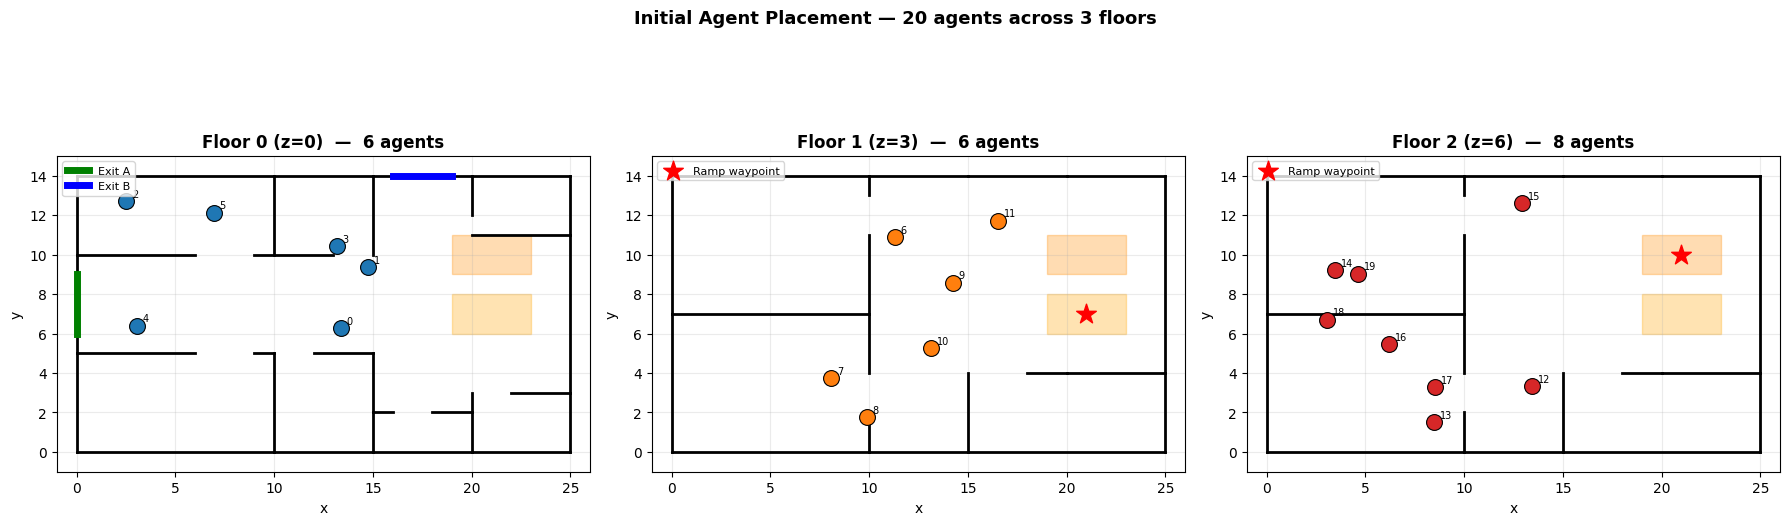

In [10]:
def init_agents(n=20, seed=42):
    rng    = np.random.default_rng(seed)
    positions, floors = [], []
    counts = [n//3, n//3, n - 2*(n//3)]   # [6, 6, 8]
    for fi, cnt in enumerate(counts):
        fz = fi * H
        for _ in range(cnt):
            while True:
                x  = rng.uniform(1., 17.)
                y  = rng.uniform(1., 13.)
                xy = np.array([x, y])
                if not any(in_ramp(xy, r) for r in RAMPS):
                    break
            positions.append(np.array([x, y, fz]))
            floors.append(fi)
    return np.array(positions, dtype=float), floors

positions_init, start_floors = init_agents(20, 42)
FLOOR_COLORS = ['#1f77b4', '#ff7f0e', '#d62728']   # blue, orange, red
AGENT_COLORS = [FLOOR_COLORS[f] for f in start_floors]

print(f"Agents per floor: {[start_floors.count(f) for f in range(3)]}")

# ── Plot initial positions on each floor ─────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for fi, ax in enumerate(axs):
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=2)
    ax.add_patch(plt.Rectangle((19,6),4,2, color='orange',     alpha=0.30))
    ax.add_patch(plt.Rectangle((19,9),4,2, color='darkorange', alpha=0.30))
    if fi == 0:
        ax.plot([0,0],[6,9],   'g-', lw=5, label='Exit A')
        ax.plot([16,19],[14,14],'b-', lw=5, label='Exit B')
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0], wp[1], c='red', s=220, marker='*', zorder=6, label='Ramp waypoint')
    idxs = [i for i,f in enumerate(start_floors) if f==fi]
    pts  = positions_init[idxs]
    ax.scatter(pts[:,0], pts[:,1], c=FLOOR_COLORS[fi], s=130,
               edgecolors='black', lw=0.8, zorder=5)
    for idx, p in zip(idxs, pts):
        ax.annotate(str(idx), (p[0]+0.3, p[1]+0.2), fontsize=7)
    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(f'Floor {fi} (z={fi*H:.0f})  —  {len(idxs)} agents', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)
plt.suptitle('Initial Agent Placement — 20 agents across 3 floors', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Simulation Loop

Each step for each active agent:

1. Compute `floor_idx = detect_floor(z)` — floor changes automatically as agent descends
2. Compute $\nabla C$ via finite differences using **that floor's** cost landscape
3. Apply momentum update + step cap
4. Check exit proximity (only possible on Floor 0)

The floor-aware cost guarantees:
- Upper-floor agents **navigate their floor's corridors** to the ramp
- Descent happens via $C_{\text{height}}$ riding the ramp incline
- Ground-floor agents **navigate ground corridors** to Exit A or Exit B


In [11]:
SIM_PARAMS = dict(
    n_agents  = 20,
    n_steps   = 1500,
    lr        = 0.06,       # learning rate
    max_step  = 0.25,       # per-component step cap
    momentum  = 0.35,       # velocity decay
    exit_tol  = 1.5,        # exit capture radius
    eps       = 1e-4,       # finite-difference epsilon
    noise     = 0.02,       # horizontal noise for saddle escape
    seed      = 42,
    # cost weights
    tau    = 1.0,
    w_wp   = 30.0,
    band   = 0.6,
    w_wall = 12.0,
    w_h    = 50.0,
    w_s    = 0.2,
    r_rep  = 0.9,
    w_rep  = 6.0,
)

def run_simulation(params=None, record_every=1, verbose=True):
    p          = params or SIM_PARAMS
    positions, _ = init_agents(n=p['n_agents'], seed=p['seed'])
    N          = len(positions)
    velocities = np.zeros((N, 3))
    escaped    = [False]*N
    escape_step= [-1]*N
    history    = []
    rng        = np.random.default_rng(p['seed']+99)

    cost_kw = {k: p[k] for k in
               ['tau','w_wp','band','w_wall','w_h','w_s','r_rep','w_rep']}

    last_step = p['n_steps'] - 1
    for step in range(p['n_steps']):
        if step % record_every == 0:
            history.append(positions.copy())

        active = [i for i in range(N) if not escaped[i]]
        if not active:
            last_step = step
            if verbose: print(f"All agents escaped at step {step}!")
            break

        new_pos = positions.copy()
        for i in active:
            p_old  = positions[i].copy()
            fi     = detect_floor(positions[i][2])  # recomputed every step

            grad   = fd_gradient(i, positions, p_old, fi, eps=p['eps'], **cost_kw)

            noise       = p['noise'] * rng.standard_normal(3)
            noise[2]    = 0.                          # no vertical noise
            velocities[i] = (p['momentum']*velocities[i]
                             - p['lr']*grad + noise)
            velocities[i] = np.clip(velocities[i], -p['max_step'], p['max_step'])

            p_new    = positions[i] + velocities[i]
            p_new[0] = np.clip(p_new[0], 0., 25.)
            p_new[1] = np.clip(p_new[1], 0., 14.)
            p_new[2] = np.clip(p_new[2], 0., 2*H+0.15)
            new_pos[i] = p_new

            # Exit detection — only relevant once agent reaches ground floor
            if fi == 0:
                for exit_pt in EXITS:
                    if np.linalg.norm(p_new - exit_pt) < p['exit_tol']:
                        escaped[i]      = True
                        escape_step[i]  = step
                        new_pos[i]      = exit_pt.copy()
                        velocities[i]   = np.zeros(3)
                        break

        positions = new_pos

    history.append(positions.copy())

    if verbose:
        n_esc = sum(escaped)
        print(f"\n{'='*48}")
        print(f"  Simulation complete")
        print(f"{'='*48}")
        print(f"  Steps run      : {last_step+1}")
        print(f"  Agents escaped : {n_esc} / {N}")
        print(f"  Stuck          : {N - n_esc}")
        print(f"{'─'*48}")
        for i in range(N):
            fi = detect_floor(positions[i][2])
            if escaped[i]:
                print(f"  Agent {i:2d}: ESCAPED  step {escape_step[i]:4d}")
            else:
                print(f"  Agent {i:2d}: STUCK    floor={fi}  pos={positions[i].round(2)}")
        print(f"{'='*48}")

    return history, escaped, escape_step, positions

print("Simulation loop defined. Ready to run.")


Simulation loop defined. Ready to run.


In [12]:
# ── RUN ───────────────────────────────────────────────────────────────────────
print("Running simulation — this may take 2–3 minutes...")
history, escaped, escape_step, final_pos = run_simulation(
    SIM_PARAMS, record_every=1, verbose=True)

history_arr = np.array(history)   # shape (frames, N, 3)
N = history_arr.shape[1]
print(f"\nTrajectory shape: {history_arr.shape}  (frames × agents × xyz)")


Running simulation — this may take 2–3 minutes...

  Simulation complete
  Steps run      : 1500
  Agents escaped : 11 / 20
  Stuck          : 9
────────────────────────────────────────────────
  Agent  0: ESCAPED  step   24
  Agent  1: ESCAPED  step   12
  Agent  2: STUCK    floor=0  pos=[ 0.39 10.42  0.  ]
  Agent  3: STUCK    floor=0  pos=[14.63 13.42  0.  ]
  Agent  4: ESCAPED  step    6
  Agent  5: STUCK    floor=0  pos=[ 1.19 10.32  0.  ]
  Agent  6: ESCAPED  step  197
  Agent  7: ESCAPED  step  519
  Agent  8: ESCAPED  step  458
  Agent  9: STUCK    floor=0  pos=[21.29  7.54  1.49]
  Agent 10: ESCAPED  step  265
  Agent 11: STUCK    floor=0  pos=[21.39  7.46  1.62]
  Agent 12: ESCAPED  step 1351
  Agent 13: STUCK    floor=2  pos=[20.97  9.52  4.88]
  Agent 14: STUCK    floor=2  pos=[20.97  9.65  4.92]
  Agent 15: STUCK    floor=1  pos=[21.32  8.69  3.5 ]
  Agent 16: ESCAPED  step  133
  Agent 17: STUCK    floor=0  pos=[20.37  8.07  1.19]
  Agent 18: ESCAPED  step  202
  Agent 19

## 8. Results & Analysis  *(Two-exit — 10 points)*

In [13]:
positions_init, start_floors = init_agents(20, SIM_PARAMS['seed'])
FLOOR_COLORS = ['#1f77b4','#ff7f0e','#d62728']
AGENT_COLORS = [FLOOR_COLORS[f] for f in start_floors]

n_esc  = sum(escaped)
exit_A = sum(1 for i in range(N) if escaped[i]
             and np.linalg.norm(final_pos[i]-EXIT_A)<1.5)
exit_B = n_esc - exit_A

print(f"Total agents   : {N}")
print(f"Escaped        : {n_esc} / {N}  ({100*n_esc/N:.0f}%)")
print(f"  via Exit A   : {exit_A}")
print(f"  via Exit B   : {exit_B}")
for fi in range(3):
    ag = [i for i,f in enumerate(start_floors) if f==fi]
    ne = sum(escaped[i] for i in ag)
    print(f"  Floor {fi} ({len(ag)} agents): {ne} escaped")


Total agents   : 20
Escaped        : 11 / 20  (55%)
  via Exit A   : 1
  via Exit B   : 10
  Floor 0 (6 agents): 3 escaped
  Floor 1 (6 agents): 4 escaped
  Floor 2 (8 agents): 4 escaped


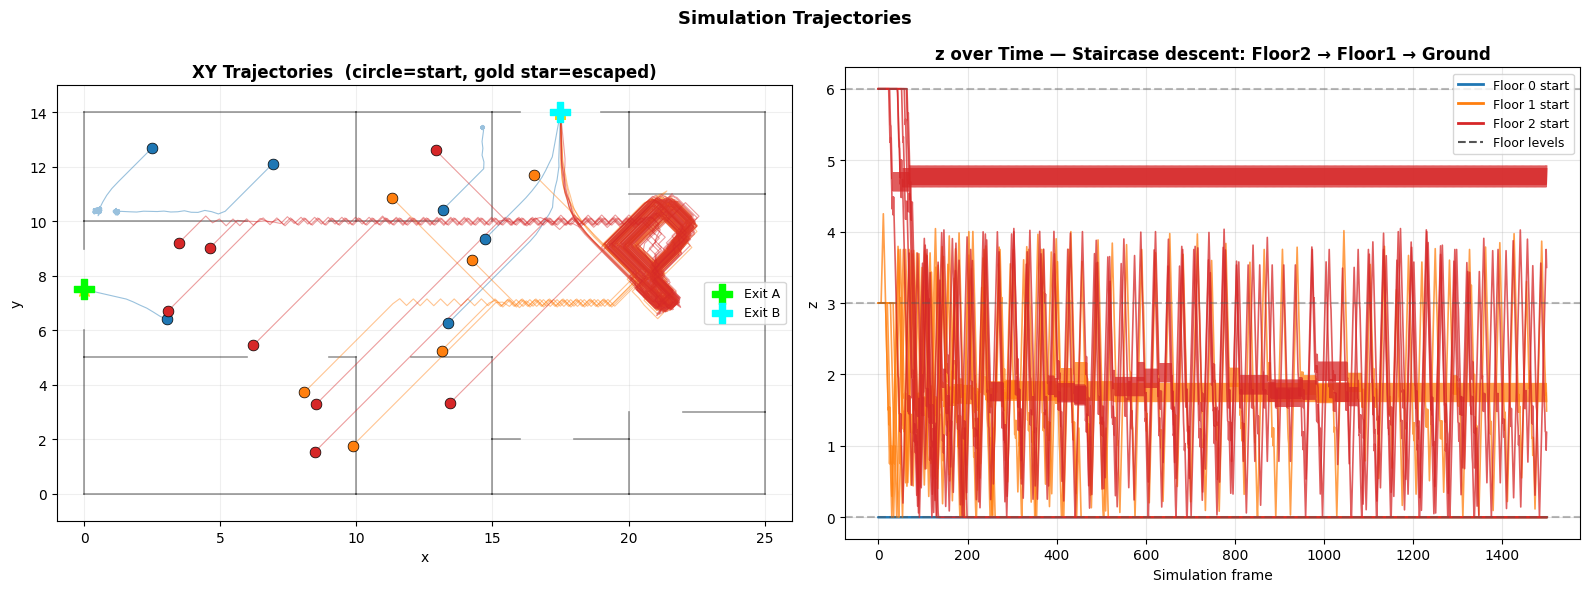

In [14]:
# ── Trajectory plots ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── XY trajectories (projected onto ground floor plan) ───────────────────────
for (x1,y1),(x2,y2) in WALLS_F0:
    ax1.plot([x1,x2],[y1,y2],'k-',lw=1.2,alpha=0.4)
for i in range(N):
    traj = history_arr[:,i,:]
    ax1.plot(traj[:,0], traj[:,1], '-', color=AGENT_COLORS[i], lw=0.8, alpha=0.45)
    ax1.scatter(traj[0,0], traj[0,1], c=AGENT_COLORS[i], s=60,
                edgecolors='k', lw=0.5, zorder=4)
    if escaped[i]:
        ax1.scatter(traj[-1,0], traj[-1,1], marker='*', c='gold', s=140, zorder=5)
ax1.scatter(*EXIT_A[:2], marker='P', c='lime', s=220, zorder=6, label='Exit A')
ax1.scatter(*EXIT_B[:2], marker='P', c='cyan', s=220, zorder=6, label='Exit B')
ax1.set_xlim(-1,26); ax1.set_ylim(-1,15); ax1.set_aspect('equal')
ax1.set_title('XY Trajectories  (circle=start, gold star=escaped)', fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2)

# ── z over time — staircase descent through ramps ────────────────────────────
for i in range(N):
    ax2.plot(history_arr[:,i,2], '-', color=AGENT_COLORS[i], lw=1.2, alpha=0.75)
for z, lbl in [(0,'z=0  Ground'),(H,f'z={H}  Floor 1'),(2*H,f'z={2*H}  Floor 2')]:
    ax2.axhline(z, color='#555', ls='--', alpha=0.4, label=lbl)
ax2.set_xlabel('Simulation frame'); ax2.set_ylabel('z')
ax2.set_title('z over Time — Staircase descent: Floor2 → Floor1 → Ground',
              fontweight='bold')
handles = [Line2D([0],[0],color=c,lw=2,label=f'Floor {f} start')
           for f,c in enumerate(FLOOR_COLORS)]
handles += [Line2D([0],[0],color='#555',ls='--',label='Floor levels')]
ax2.legend(handles=handles, fontsize=9); ax2.grid(True, alpha=0.3)
plt.suptitle('Simulation Trajectories', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


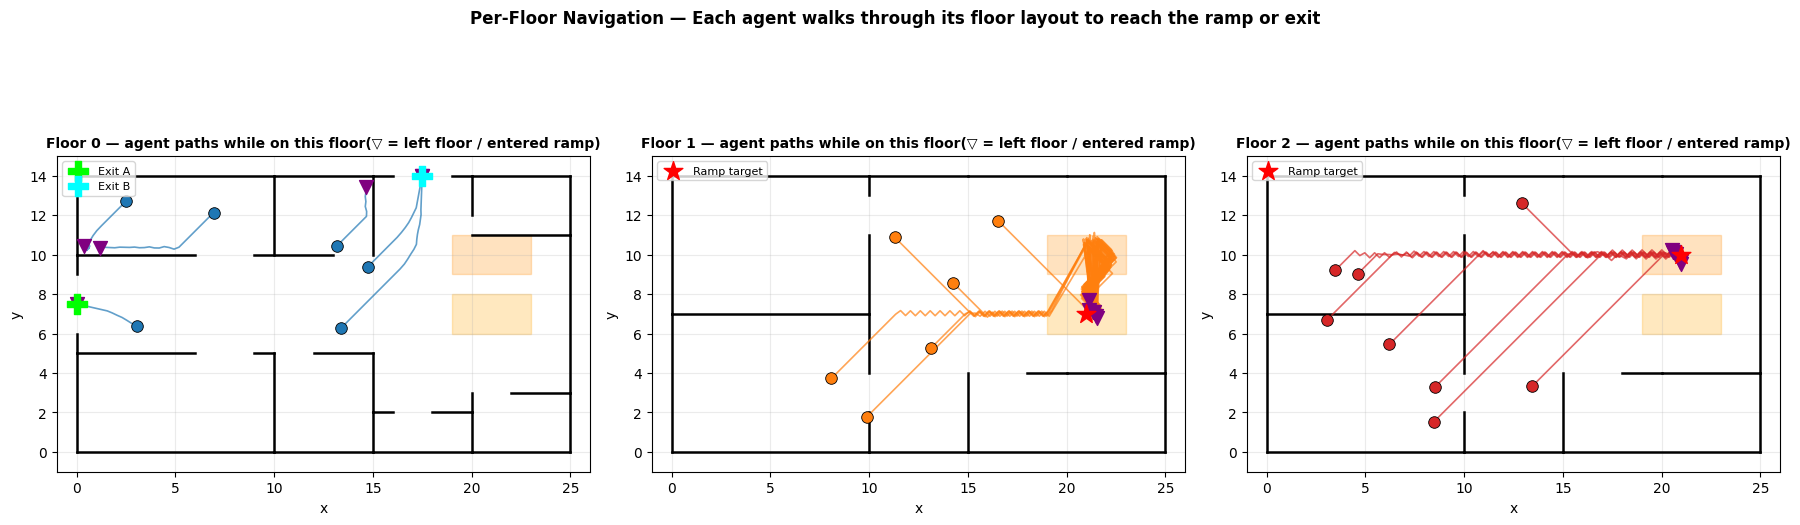

In [16]:
# ── Per-floor XY trajectories (agents navigate their own floor) ───────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for fi, ax in enumerate(axs):
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=1.8)
    ax.add_patch(plt.Rectangle((19,6),4,2,color='orange',    alpha=0.25))
    ax.add_patch(plt.Rectangle((19,9),4,2,color='darkorange',alpha=0.25))

    # For agents that STARTED on this floor, show only the portion of
    # their trajectory while they were on this floor
    idxs = [i for i,f in enumerate(start_floors) if f==fi]
    for i in idxs:
        traj = history_arr[:,i,:]
        # Frames where detect_floor(z) == fi
        mask  = np.array([detect_floor(z)==fi for z in traj[:,2]])
        segs  = traj[mask]
        if len(segs) > 1:
            ax.plot(segs[:,0], segs[:,1], '-', color=FLOOR_COLORS[fi],
                    lw=1.2, alpha=0.7)
            ax.scatter(segs[0,0],  segs[0,1],  c=FLOOR_COLORS[fi],
                       s=70, edgecolors='k', lw=0.6, zorder=4)
            # Mark where agent leaves this floor (enters ramp)
            ax.scatter(segs[-1,0], segs[-1,1], marker='v', c='purple',
                       s=100, zorder=5)

    if fi == 0:
        ax.scatter(*EXIT_A[:2], marker='P', c='lime', s=200, zorder=6, label='Exit A')
        ax.scatter(*EXIT_B[:2], marker='P', c='cyan', s=200, zorder=6, label='Exit B')
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0],wp[1], c='red', s=200, marker='*', zorder=6, label='Ramp target')

    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(f'Floor {fi} — agent paths while on this floor(▽ = left floor / entered ramp)', fontweight='bold', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)

plt.suptitle('Per-Floor Navigation — Each agent walks through its floor layout to reach the ramp or exit',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


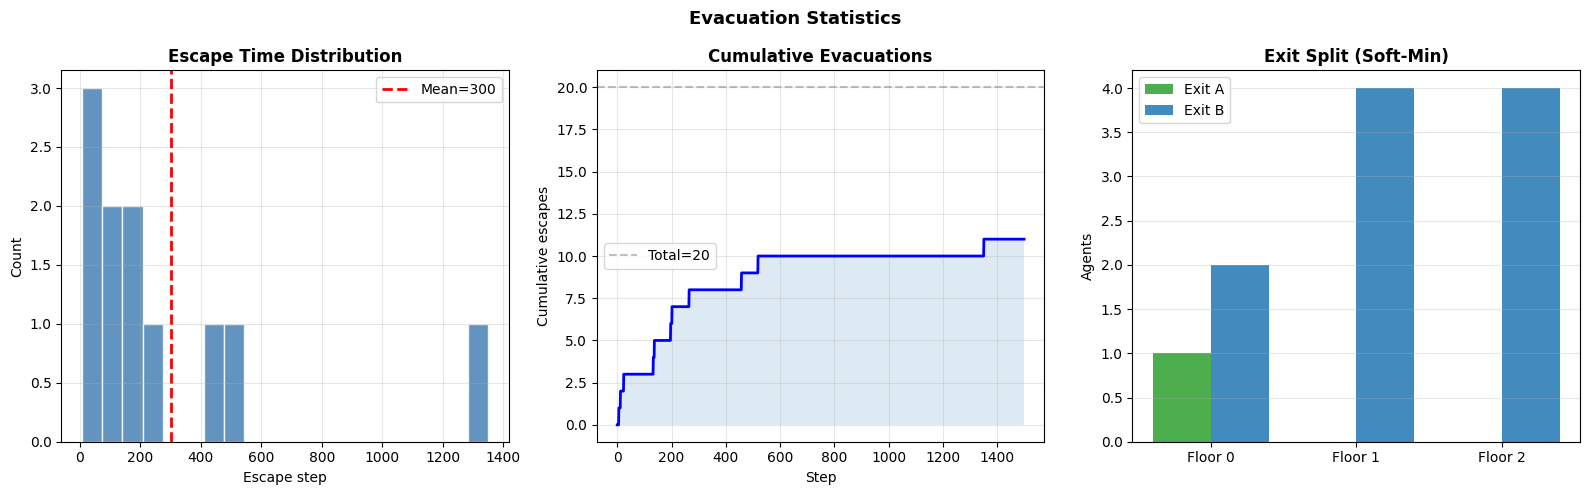

In [17]:
# ── Statistics charts ─────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Escape time histogram
esc_times = [escape_step[i] for i in range(N) if escaped[i]]
if esc_times:
    axs[0].hist(esc_times, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axs[0].axvline(np.mean(esc_times), color='red', lw=2, ls='--',
                   label=f'Mean={np.mean(esc_times):.0f}')
axs[0].set_xlabel('Escape step'); axs[0].set_ylabel('Count')
axs[0].set_title('Escape Time Distribution', fontweight='bold')
axs[0].legend(); axs[0].grid(True, alpha=0.3)

# Cumulative escapes
steps = np.arange(SIM_PARAMS['n_steps'])
cum   = np.array([sum(1 for i in range(N)
                  if escaped[i] and escape_step[i]<=s) for s in steps])
axs[1].plot(steps, cum, 'b-', lw=2)
axs[1].fill_between(steps, cum, alpha=0.15)
axs[1].axhline(N, color='grey', ls='--', alpha=0.5, label=f'Total={N}')
axs[1].set_xlabel('Step'); axs[1].set_ylabel('Cumulative escapes')
axs[1].set_title('Cumulative Evacuations', fontweight='bold')
axs[1].legend(); axs[1].grid(True, alpha=0.3)

# Exit split by starting floor
x_pos = np.arange(3)
eA = [sum(1 for i in range(N) if start_floors[i]==f and escaped[i]
          and np.linalg.norm(final_pos[i]-EXIT_A)<1.5) for f in range(3)]
eB = [sum(1 for i in range(N) if start_floors[i]==f and escaped[i]
          and np.linalg.norm(final_pos[i]-EXIT_B)<1.5) for f in range(3)]
axs[2].bar(x_pos-0.2, eA, 0.4, label='Exit A', color='#2ca02c', alpha=0.85)
axs[2].bar(x_pos+0.2, eB, 0.4, label='Exit B', color='#1f77b4', alpha=0.85)
axs[2].set_xticks(x_pos); axs[2].set_xticklabels(['Floor 0','Floor 1','Floor 2'])
axs[2].set_ylabel('Agents'); axs[2].set_title('Exit Split (Soft-Min)', fontweight='bold')
axs[2].legend(); axs[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Evacuation Statistics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. 3D Animation  *(Visualization — 10 points)*

The animation uses **your floor1.py / floor2.py / floor3.py geometry directly**.

How it works:
1. Each floor file is imported with `vedo.show` suppressed so geometry is built but not displayed
2. All objects except the per-floor `Axes` (Assembly) and `Text3D` label are extracted
3. A unified axes + title is added once for the combined 3-floor view
4. Agent spheres coloured by starting floor are placed at their 3D positions each frame
5. Frames are rendered offscreen via Xvfb and encoded to MP4 with ffmpeg

**floor1.py** — ground floor walls, exits, Ramp 1 surface  
**floor2.py** — Floor 1 walls, both ramp surfaces visible  
**floor3.py** — Floor 2 walls, Ramp 2 surface  


In [18]:
# ── Load geometry from your floor files ──────────────────────────────────────
# floor1.py / floor2.py / floor3.py must be in the same directory as this notebook.

_real_show = vedo.show
vedo.show  = lambda *a, **kw: None      # suppress per-floor vedo.show() calls

import importlib, sys

# Force reimport in case they were already imported
for mod in ['floor1','floor2','floor3']:
    if mod in sys.modules: del sys.modules[mod]

import floor1, floor2, floor3

vedo.show  = _real_show                 # restore

def strip_chrome(scene):
    """
    Remove the per-floor Axes (Assembly) and Text3D floor label.
    Keep all pure geometry: walls, slabs, ramps, columns, doors, exits.
    """
    return [o for o in scene
            if type(o).__name__ not in ('Assembly', 'Text3D')]

building = (strip_chrome(floor1.scene)
          + strip_chrome(floor2.scene)
          + strip_chrome(floor3.scene))

# One unified axes + title for the combined 3-floor view
unified_axes  = vedo.Axes(xrange=(0,26), yrange=(0,15), zrange=(0,3*H+2),
                          xtitle='x', ytitle='y', ztitle='z', axes_linewidth=2)
unified_title = vedo.Text3D('Crawford Building — Evacuation',
                            pos=(0.5, 0.3, 3*H+0.8), s=0.42, c='navy')

print(f"Geometry loaded from your floor files:")
print(f"  floor1.py : {len(strip_chrome(floor1.scene)):3d} objects")
print(f"  floor2.py : {len(strip_chrome(floor2.scene)):3d} objects")
print(f"  floor3.py : {len(strip_chrome(floor3.scene)):3d} objects")
print(f"  Total     : {len(building):3d} building objects")


[vedo.text3d:323] WARNING: unavailable characters in font name 'Normografo': {'—'}.
Type "vedo -r fonts" for a demo.
Geometry loaded from your floor files:
  floor1.py :  63 objects
  floor2.py :  48 objects
  floor3.py :  37 objects
  Total     : 148 building objects


In [19]:
# ── Render animation DIRECTLY to MP4 using vedo.Video ────────────────────────
# vedo.Video pipes frames straight to ffmpeg — no temp frames directory needed.

OUTPUT_MP4   = os.path.join(os.path.abspath("."), "evacuation.mp4")
RECORD_EVERY = 3      # use every 3rd simulation frame
FPS          = 60
W_WIN, H_WIN = 1280, 720

render_frames = history[::RECORD_EVERY]
n_frames      = len(render_frames)

# Agent colours (by starting floor)
_init_pos, _start_floors = init_agents(20, SIM_PARAMS["seed"])
FLOOR_COLORS = ["#1f77b4", "#ff7f0e", "#d62728"]
AGENT_COLORS = [FLOOR_COLORS[f] for f in _start_floors]

# Camera angle — same as your floor files
CAM = dict(pos=(65,-22,45), focal_point=(12,7,4.5), viewup=(0,0,1))

# Start Xvfb virtual display for offscreen rendering
vedo.settings.start_xvfb()

# Open vedo.Video — streams frames directly to MP4 via ffmpeg, no disk frames
video = vedo.Video(OUTPUT_MP4, fps=FPS, backend="ffmpeg")

print(f"Rendering {n_frames} frames → {OUTPUT_MP4}")

for frame_idx, positions_frame in enumerate(render_frames):
    sim_step = frame_idx * RECORD_EVERY
    n_esc    = sum(1 for i in range(N)
                   if escaped[i] and escape_step[i] <= sim_step)

    plt_vedo = vedo.Plotter(size=(W_WIN, H_WIN), offscreen=True,
                             bg="#f5f5f0", bg2="#ddeeff")

    # ── Your floor geometry (floor1/2/3.py) ──────────────────────────────────
    for obj in building:
        plt_vedo.add(obj)
    plt_vedo.add(unified_axes, unified_title)

    # ── Agent spheres (coloured by starting floor) ────────────────────────────
    for i in range(N):
        pos = positions_frame[i]
        if escaped[i] and escape_step[i] <= sim_step:
            # Faded grey ghost at exit position
            sph = vedo.Sphere(pos=pos, r=0.22).color("#aaaaaa").alpha(0.35)
        else:
            # Active — lifted slightly above surface so visible above floor slab
            sph = vedo.Sphere(pos=pos + np.array([0, 0, 0.28]), r=0.40)
            sph.color(AGENT_COLORS[i]).alpha(0.95)
        plt_vedo.add(sph)

    # ── HUD ───────────────────────────────────────────────────────────────────
    plt_vedo.add(vedo.Text2D(
        f"Step {sim_step:4d}    Escaped: {n_esc:2d}/{N}",
        pos="top-left", s=1.15, c="navy", bg="white", alpha=0.72, font="Courier"))
    plt_vedo.add(vedo.Text2D(
        u"\u25cf Blue=Floor0  \u25cf Orange=Floor1  "
        u"\u25cf Red=Floor2  \u25cf Grey=Escaped",
        pos="bottom-left", s=0.88, c="darkblue", bg="white", alpha=0.62, font="Courier"))

    # ── Pipe this frame straight into the video stream ────────────────────────
    plt_vedo.show(camera=CAM, interactive=False)
    video.add_frame()
    plt_vedo.close()

    if frame_idx % 50 == 0:
        print(f"  frame {frame_idx:4d}/{n_frames}  step={sim_step:5d}  escaped={n_esc}/{N}")

# Finalise — flushes ffmpeg buffer and closes the file
video.close()

if os.path.exists(OUTPUT_MP4):
    print(f"\nDone!  {OUTPUT_MP4}  ({os.path.getsize(OUTPUT_MP4)/1e6:.1f} MB)")
else:
    print("\nERROR: video file was not written. Check that ffmpeg is installed.")


starting xvfb (can take a minute) ...

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [ ]:
# ── Display the video inline ──────────────────────────────────────────────────
from IPython.display import Video, display
if os.path.exists('./evacuation.mp4'):
    display(Video('./evacuation.mp4', width=900, embed=True))
else:
    print("Video not found — run the rendering cell above first.")


## 10. Summary

### How per-floor navigation works end-to-end

```
Step 1:  Agent on Floor 2 (z≈6)
         detect_floor(z) = 2
         C_goal = w_wp * ||(x,y) - (21,10)||²   ← pulls toward Ramp 2 entry
         C_walls uses WALLS_UPPER                ← agent must go around walls/through doors
         → Agent walks through Floor 2 corridors to reach x≈21, y≈10

Step 2:  Agent enters Ramp 2 capsule footprint (dist to segment ≤ 1.0)
         z_surf switches from z=6 (flat floor) to z_ramp(x,y) (incline)
         C_height = 50*(z - z_ramp(x,y))²       ← pulls z down as x moves 23→19
         → Agent descends ramp from z=6 to z=3

Step 3:  Agent reaches z≈3,  detect_floor(z) = 1
         C_goal switches to Ramp 1 entry (21, 7)
         C_walls switches to WALLS_UPPER (Floor 1 layout)
         → Agent navigates Floor 1 corridors to reach ramp

Step 4:  Agent descends Ramp 1 (z: 3→0),  detect_floor(z) = 0
         C_goal switches to soft-min over Exit A and Exit B
         C_walls switches to WALLS_F0 (Ground floor layout)
         → Agent navigates ground floor to whichever exit is more accessible
         → Exits through Exit A or Exit B
```

| Component | Implementation |
|---|---|
| Per-floor navigation | `cost_goal` and `cost_walls` keyed on `detect_floor(z)` |
| Ramp descent | `C_height` rides agent down inclined surface automatically |
| Soft-min exits | $\tau=1.0$, differentiable, natural crowd split |
| Gradient | Central finite differences $\varepsilon=10^{-4}$ |
| Stability | Momentum $\beta=0.35$, step cap $s_{\max}=0.25$, noise $\sigma=0.02$ |
| Visualization | floor1/2/3.py geometry used directly — 148 objects |
